# Single-Cell RNA-seq Analysis + ML-based Cell Classification

## Objective
This project analyzes messy single-cell RNA-seq data to:
- Clean and preprocess biological data
- Perform exploratory data analysis (EDA)
- Visualize gene expression patterns
- Classify cell types using Machine Learning

## Dataset Features
- 1000 cells
- 20 gene expression features
- Batch and Condition metadata
- Includes missing values and noisy entries

## Steps Performed
1. Data Cleaning (handling missing values and errors)
2. Feature Engineering
3. Visualization (histograms, boxplots, PCA)
4. Machine Learning Classification
5. Model Evaluation

## Outcome
- Identify patterns in gene expression
- Predict cell types
- Understand important genes influencing classification

Saving single_cell_messy_dataset.csv to single_cell_messy_dataset.csv
Initial Data:
  Cell_ID Cell_Type   Batch Condition              Gene_1              Gene_2  \
0  Cell_0        NK  Batch2   Disease   60.12347333609323   51.30607571776618   
1  Cell_1    B-cell  Batch2   Healthy   33.24248569430128  49.191015520162225   
2  Cell_2        NK  Batch3   Healthy  44.225950262205956  49.293254757233896   
3  Cell_3  Monocyte  Batch2   Disease    58.5305816779828  43.233952899357334   
4  Cell_4        NK  Batch2   Healthy                 NaN   49.63549979765678   

               Gene_3              Gene_4              Gene_5  \
0   52.36295575186261   32.95969968281773  36.725900928081764   
1   52.87628367321822  44.222762560815035                 NaN   
2  52.015176586449535   41.66132521126649   46.76748462999171   
3   61.24583823772247  25.285562351241722  50.152739451151426   
4  63.625883628656396  41.273153285871516               error   

              Gene_6  ...             

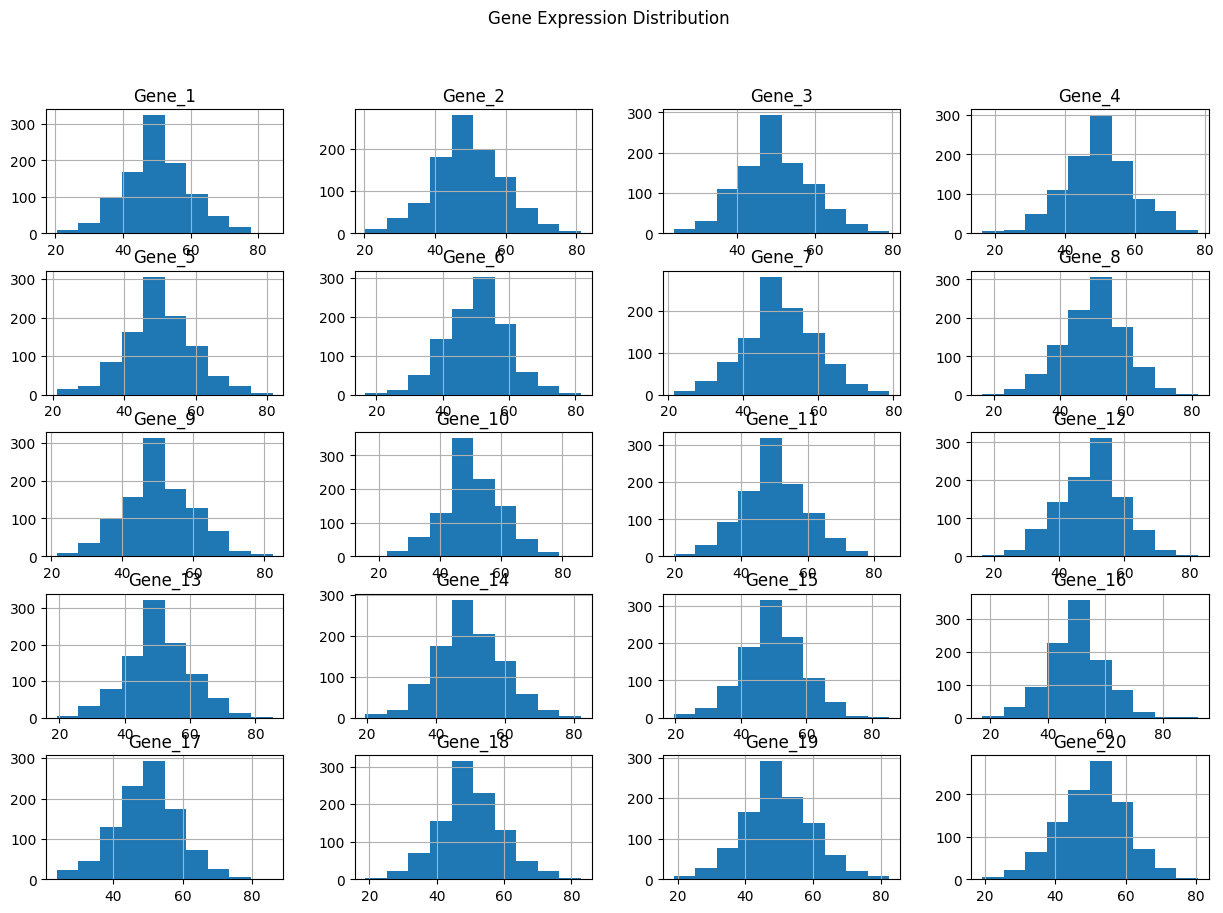

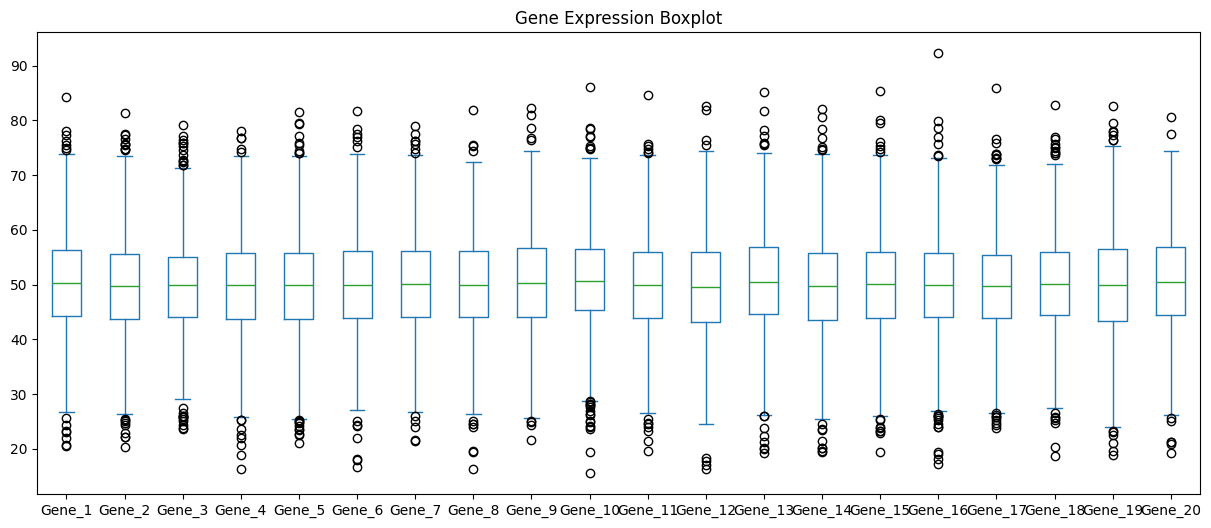

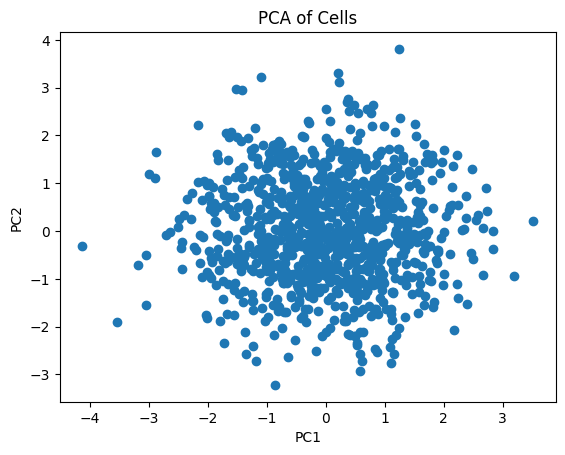


Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.33      0.27        40
           1       0.19      0.16      0.17        51
           2       0.26      0.14      0.18        37
           3       0.31      0.23      0.26        40
           4       0.09      0.16      0.11        32

    accuracy                           0.20       200
   macro avg       0.22      0.20      0.20       200
weighted avg       0.22      0.20      0.20       200


Confusion Matrix:
[[13  6  3  7 11]
 [15  8  4  6 18]
 [ 7 12  5  3 10]
 [10  5  5  9 11]
 [10 11  2  4  5]]


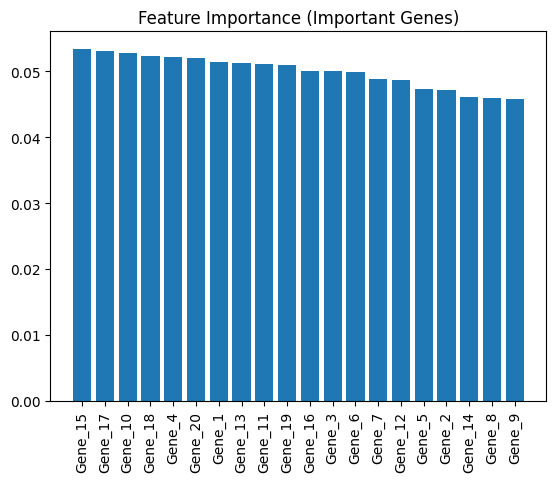

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# Upload file from your computer
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv(list(uploaded.keys())[0])

print("Initial Data:")
print(df.head())

# -------------------------------
# Data Cleaning
# -------------------------------

# Replace 'error' with NaN
df.replace("error", np.nan, inplace=True)

# Convert gene columns to numeric
gene_cols = [col for col in df.columns if "Gene" in col]
df[gene_cols] = df[gene_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
df[gene_cols] = df[gene_cols].fillna(df[gene_cols].mean())

print("\nAfter Cleaning:")
print(df.head())

# -------------------------------
# Exploratory Data Analysis
# -------------------------------

# Histogram
df[gene_cols].hist(figsize=(15,10))
plt.suptitle("Gene Expression Distribution")
plt.show()

# Boxplot
df[gene_cols].plot(kind='box', figsize=(15,6))
plt.title("Gene Expression Boxplot")
plt.show()

# -------------------------------
# PCA Visualization
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[gene_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA of Cells")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# Machine Learning
# -------------------------------

# Encode target variable
le = LabelEncoder()
df['Cell_Type'] = le.fit_transform(df['Cell_Type'])

X = df[gene_cols]
y = df['Cell_Type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -------------------------------
# Results
# -------------------------------

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------
# Feature Importance
# -------------------------------

importances = model.feature_importances_
feat_df = pd.DataFrame({"Gene": gene_cols, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.bar(feat_df["Gene"], feat_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance (Important Genes)")
plt.show()